## Cross-validation featurization-grid analysis

This notebook loads the results of the four `pipeline/train_cv.py` runs that
cover the 2x2 peptide x organism featurization grid (peptide:
`rdkit_descriptors` vs `peptideclm_embedding`; organism: `vocab_embedding`
vs `kmer_composition`; architecture held fixed at `attention_fusion_classifier`)
directly from Weights & Biases, and analyzes them from several angles:

1. Per-fold overfit/underfit behavior of each featurization combination,
   with precision/recall given the primary narrative weight.
2. The overall effect of featurization choice on cross-validated
   performance ("the whole picture").
3. Breakdown by organism (*E. coli*, *S. aureus*, *P. aeruginosa* -- the
   only organisms currently in-scope per `config/thresholds/organism_thresholds.csv`).
4. Breakdown by `has_noncanonical` -- **the primary objective**: does any
   featurization choice meaningfully help (or hurt) performance on
   non-canonical/cyclic peptides specifically, as opposed to the dataset
   overall?
5. Whether the training loop (5 epochs per fold) looks like it would
   benefit from running longer, to the extent the currently-logged data
   can answer that.

Source runs: wandb project `soamp`, group `featurization_grid_cv_v1`,
`job_type="kfold_cv"` -- `rdkit_vocab_cv`, `rdkit_kmer_cv`,
`peptideclm_vocab_cv`, `peptideclm_kmer_cv` (`config/train/cv_{rdkit,peptideclm}_{vocab,kmer}.yaml`),
run 2026-09-14. Each fits 5-fold CV over the same `data/train_folds_leiden.csv`
Leiden-community fold assignments (identical folds across all four runs --
only the featurization differs), never touching the held-out test split.


In [1]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import wandb
from dotenv import load_dotenv

from soamp.engine.metrics import compute_binary_metrics, compute_metrics_by_organism

load_dotenv()
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 140)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

METRICS = ["accuracy", "f1", "precision", "recall", "auroc"]
EXP_IDS = ["rdkit_vocab_cv", "rdkit_kmer_cv", "peptideclm_vocab_cv", "peptideclm_kmer_cv"]
COLORS = dict(zip(EXP_IDS, ["tab:blue", "tab:orange", "tab:green", "tab:red"]))


### 1. Load the four CV runs

Runs are located by `group="featurization_grid_cv_v1"` rather than by name
pattern, since that's the field the four `cv_*.yaml` configs set
specifically to group them for comparison (`wandb_group`,
`config/train/cv_rdkit_vocab.yaml`).


In [2]:
PROJECT = "soamp"
GROUP = "featurization_grid_cv_v1"

api = wandb.Api()
entity = os.environ.get("WANDB_ENTITY") or api.default_entity
runs = {r.name: r for r in api.runs(f"{entity}/{PROJECT}", filters={"group": GROUP})}

missing = set(EXP_IDS) - set(runs)
assert not missing, f"missing expected runs: {missing}"

for exp_id in EXP_IDS:
    r = runs[exp_id]
    print(f"{exp_id:22s} state={r.state:10s} tags={r.tags}")


wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.


rdkit_vocab_cv         state=finished   tags=['attention_fusion_classifier', 'cv', 'rdkit_descriptors', 'vocab_embedding']
rdkit_kmer_cv          state=finished   tags=['attention_fusion_classifier', 'cv', 'kmer_composition', 'rdkit_descriptors']
peptideclm_vocab_cv    state=finished   tags=['attention_fusion_classifier', 'cv', 'peptideclm_embedding', 'vocab_embedding']
peptideclm_kmer_cv     state=finished   tags=['attention_fusion_classifier', 'cv', 'kmer_composition', 'peptideclm_embedding']


### 2. Load each run's `cv_results` artifact

**Important gotcha, verified directly against the live project**: all four
runs log an artifact with the *same name*, `cv_results` (see
`pipeline/train_cv.py`) -- wandb versions artifacts within one name per
*project*, not per run, so `cv_results:latest` project-wide only resolves
to whichever of the four runs logged last. Each run object's own
`run.logged_artifacts()` is used instead, which correctly scopes to just
that run's own version.

The reloaded wandb `Table` returns every column as a Python `str` except
the numeric ones already stored as numeric server-side
(`true_label_int`/`pred_label_int`/`logit`/`prob`) -- `has_noncanonical`,
`correct`, `fold_id`, `val_fold_id` need explicit casts back.


In [3]:
BOOL_COLS = ["has_noncanonical", "correct"]
INT_COLS = ["true_label_int", "pred_label_int", "fold_id", "val_fold_id"]
FLOAT_COLS = ["logit", "prob", "mic_value_uM"]


def _to_bool(series: pd.Series) -> pd.Series:
    # NOT `series.dtype == object`: wandb Tables reload string columns as a
    # "str"/StringDtype (pandas >= 2.x with the pyarrow string backend), not
    # plain `object` -- that check silently took the wrong branch and did
    # `.astype(bool)` directly on the strings "True"/"False", and since
    # *any* non-empty string is truthy in Python, "False" became True too.
    if pd.api.types.is_bool_dtype(series):
        return series
    return series.astype(str).map({"True": True, "False": False}).astype(bool)


def load_cv_results(run) -> pd.DataFrame:
    artifacts = [a for a in run.logged_artifacts() if a.name.startswith("cv_results")]
    assert len(artifacts) == 1, f"{run.name}: expected exactly one cv_results artifact, got {[a.name for a in artifacts]}"
    table = artifacts[0].get("cv_results")
    df = pd.DataFrame(table.data, columns=table.columns)
    for col in BOOL_COLS:
        df[col] = _to_bool(df[col])
    for col in INT_COLS:
        df[col] = df[col].astype(int)
    for col in FLOAT_COLS:
        df[col] = df[col].astype(float)
    return df


cv_results = {exp_id: load_cv_results(runs[exp_id]) for exp_id in EXP_IDS}
for exp_id, df in cv_results.items():
    print(f"{exp_id:22s} rows={len(df):6d} folds={sorted(df['val_fold_id'].unique())}")


wandb:   1 of 1 files downloaded.  


wandb:   1 of 1 files downloaded.  


wandb:   1 of 1 files downloaded.  


wandb:   1 of 1 files downloaded.  


rdkit_vocab_cv         rows= 85215 folds=[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
rdkit_kmer_cv          rows= 85215 folds=[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
peptideclm_vocab_cv    rows= 85215 folds=[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
peptideclm_kmer_cv     rows= 85215 folds=[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]


### 3. Schema walkthrough

Row grain is one row per (dataset row x eval_group) per CV round. Three
columns that are easy to conflate:

- **`fold_id`** -- the row's own *permanent* Leiden-cluster fold
  assignment (0-4), fixed regardless of which CV round is being scored.
- **`val_fold_id`** -- which CV round this particular row was scored in
  (0-4).
- **`eval_group`** -- `"fit"` or `"val"` *for that round*.

A row with `fold_id=2` shows up as `eval_group="val"` only in the round
where `val_fold_id=2`, and as `eval_group="fit"` in the other four rounds.
Concretely:


In [4]:
example = cv_results["rdkit_vocab_cv"]
cols = ["peptide_id", "organism", "has_noncanonical", "label", "fold_id", "val_fold_id", "eval_group", "pred_label_int", "prob"]
example[example["fold_id"] == 2].sort_values("val_fold_id")[cols].head(10)


,peptide_id,organism,has_noncanonical,label,fold_id,val_fold_id,eval_group,pred_label_int,prob
6,77,Staphylococcus aureus,True,active,2,0,fit,1,0.731233
9737,16568,Escherichia coli,True,active,2,0,fit,1,0.879458
9738,16584,Staphylococcus aureus,False,active,2,0,fit,0,0.322933
9739,16584,Escherichia coli,False,active,2,0,fit,1,0.519428
9740,16584,Pseudomonas aeruginosa,False,active,2,0,fit,0,0.453445
9741,16585,Staphylococcus aureus,False,active,2,0,fit,0,0.299609
9742,16585,Escherichia coli,False,active,2,0,fit,1,0.526887
9743,16585,Pseudomonas aeruginosa,False,active,2,0,fit,0,0.451649
9744,16586,Staphylococcus aureus,False,active,2,0,fit,0,0.284359
9745,16586,Escherichia coli,False,active,2,0,fit,0,0.495832


### 4. Sanity checks

Cross-check the row-level `cv_results` table against each run's
per-fold summary history (`run.history()`, logged once per fold via
`run.log({"fold": ..., "fit/...": ..., "val/...": ..., "n_fit": ..., "n_val": ...})`
in `pipeline/train_cv.py`) -- the two should agree exactly on row counts.


In [5]:
def fold_history(run) -> pd.DataFrame:
    hist = run.history()
    cols = [
        "fold", "n_fit", "n_val",
        "fit/accuracy", "fit/f1", "fit/precision", "fit/recall", "fit/auroc",
        "val/accuracy", "val/f1", "val/precision", "val/recall", "val/auroc",
    ]
    hist = hist[cols].dropna(subset=["fold"]).sort_values("fold").reset_index(drop=True)
    hist["fold"] = hist["fold"].astype(int)
    return hist


fold_metrics = {exp_id: fold_history(runs[exp_id]) for exp_id in EXP_IDS}

for exp_id in EXP_IDS:
    df = cv_results[exp_id]
    hist = fold_metrics[exp_id]
    for _, row in hist.iterrows():
        fold = int(row["fold"])
        n_fit_actual = int(((df["val_fold_id"] == fold) & (df["eval_group"] == "fit")).sum())
        n_val_actual = int(((df["val_fold_id"] == fold) & (df["eval_group"] == "val")).sum())
        assert n_fit_actual == row["n_fit"], (exp_id, fold, "n_fit", n_fit_actual, row["n_fit"])
        assert n_val_actual == row["n_val"], (exp_id, fold, "n_val", n_val_actual, row["n_val"])

print("OK: row-level cv_results counts match run.history()'s n_fit/n_val for every fold, all 4 runs.")

loss_cols = sorted({c for run in runs.values() for c in run.history().columns if "loss" in c.lower()})
print("history columns containing 'loss' across all 4 runs:", loss_cols)


OK: row-level cv_results counts match run.history()'s n_fit/n_val for every fold, all 4 runs.


history columns containing 'loss' across all 4 runs: []


**Limitation, confirmed above: no loss is logged anywhere** -- not
per-epoch, not even a single final fit/val loss value. Looking at
`src/soamp/engine/cross_validation.py::train_and_evaluate_fold`, the
per-epoch `trainer.train_epoch(fit_loader)` return value (`{"loss": ...}`)
is discarded in the training loop, and `trainer.evaluate()`'s `"loss"` key
is never read either -- only the logits/labels needed for
`compute_binary_metrics` are used. `wandb.watch` (`log="all"`) does log
gradient/parameter-weight histograms, but that is not a loss curve.

So Section 7 below ("would more training help?") cannot use a real loss
trajectory -- it instead uses the fit-set metric level and the fit-vs-val
gap (computed in Section 5) as an indirect proxy, and calls out explicitly
where the real answer would need per-epoch loss logging added to
`Trainer`/`train_and_evaluate_fold`/`pipeline/train_cv.py` and the CV
re-run (out of scope here, at the user's direction -- this notebook
analyzes the CV results as already logged).


### 5. Per-fold overfit / underfit, per featurization

Fit-set metrics measure how well each fold's model fit the data it was
trained on; val-set metrics measure generalization to the held-out fold.
A large fit-minus-val gap on a given metric is the overfitting signal; a
fit-set metric that is itself unremarkable (not near-ceiling) alongside a
*small* gap is closer to underfitting. Precision and recall get top
billing per the framing of this analysis; accuracy/F1/AUROC are shown
alongside for completeness.


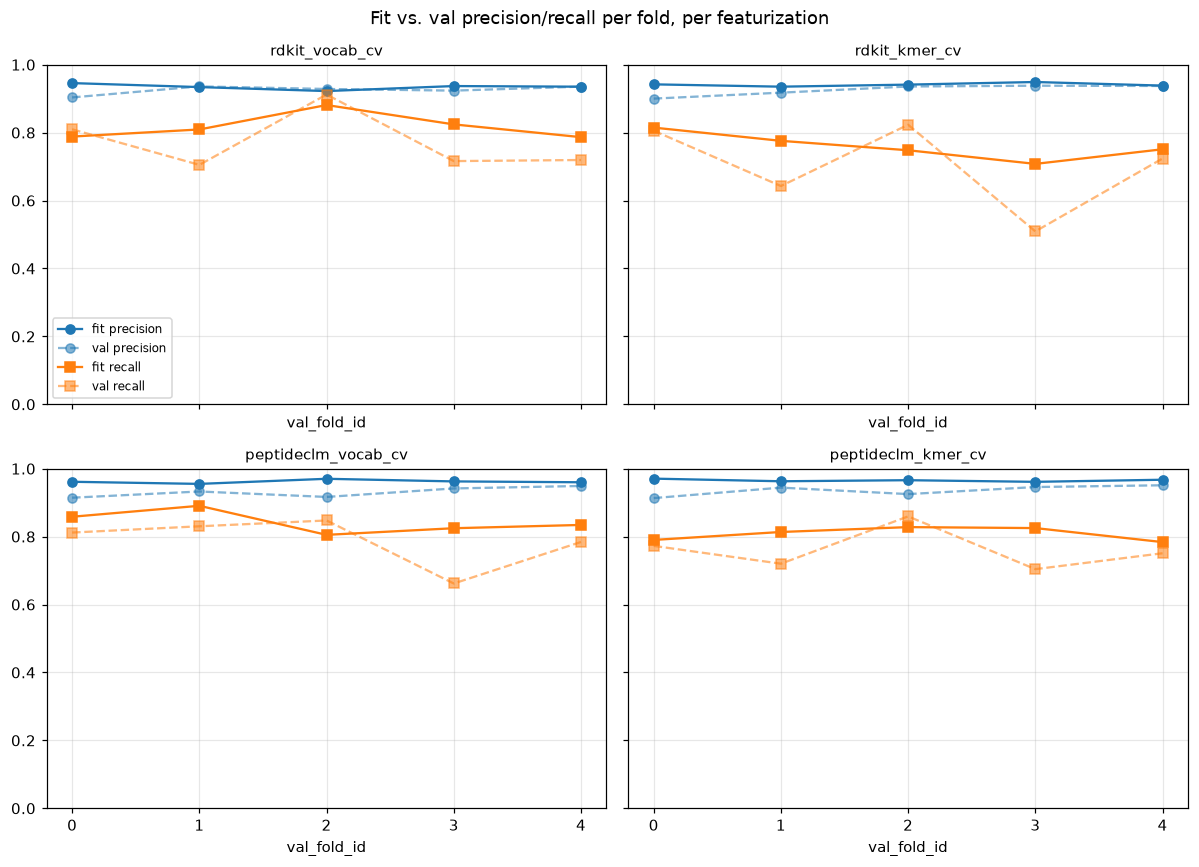

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8), sharex=True, sharey=True)
for ax, exp_id in zip(axes.flat, EXP_IDS):
    hist = fold_metrics[exp_id]
    ax.plot(hist["fold"], hist["fit/precision"], "o-", color="tab:blue", label="fit precision")
    ax.plot(hist["fold"], hist["val/precision"], "o--", color="tab:blue", alpha=0.55, label="val precision")
    ax.plot(hist["fold"], hist["fit/recall"], "s-", color="tab:orange", label="fit recall")
    ax.plot(hist["fold"], hist["val/recall"], "s--", color="tab:orange", alpha=0.55, label="val recall")
    ax.set_title(exp_id, fontsize=10)
    ax.set_xlabel("val_fold_id")
    ax.set_xticks(hist["fold"])
    ax.set_ylim(0, 1)
axes.flat[0].legend(fontsize=8, loc="lower left")
fig.suptitle("Fit vs. val precision/recall per fold, per featurization")
fig.tight_layout()
plt.show()


In [7]:
def gap_table(exp_id: str) -> pd.DataFrame:
    hist = fold_metrics[exp_id].copy()
    for m in METRICS:
        hist[f"gap_{m}"] = hist[f"fit/{m}"] - hist[f"val/{m}"]
    hist.insert(0, "exp_id", exp_id)
    return hist


gap_df = pd.concat([gap_table(e) for e in EXP_IDS], ignore_index=True)
gap_cols = ["exp_id", "fold"] + [f"gap_{m}" for m in METRICS]
gap_df[gap_cols].round(3)


,exp_id,fold,gap_accuracy,gap_f1,gap_precision,gap_recall,gap_auroc
0,rdkit_vocab_cv,0,0.008,0.006,0.042,-0.021,0.082
1,rdkit_vocab_cv,1,0.080,0.063,-0.002,0.104,0.036
2,rdkit_vocab_cv,2,-0.026,-0.019,-0.006,-0.031,0.031
3,rdkit_vocab_cv,3,0.091,0.070,0.013,0.108,0.078
4,rdkit_vocab_cv,4,0.061,0.041,-0.000,0.067,0.050
5,rdkit_kmer_cv,0,0.033,0.024,0.042,0.009,0.081
6,rdkit_kmer_cv,1,0.116,0.092,0.018,0.133,0.075
7,rdkit_kmer_cv,2,-0.050,-0.042,0.006,-0.075,0.029
8,rdkit_kmer_cv,3,0.159,0.151,0.011,0.199,0.071
9,rdkit_kmer_cv,4,0.030,0.017,0.001,0.027,0.047


In [8]:
gap_summary = gap_df.groupby("exp_id")[[f"gap_{m}" for m in METRICS]].agg(["mean", "std"]).round(3)
gap_summary


gap_accuracy        gap_f1        gap_precision        gap_recall        gap_auroc       
                            mean    std   mean    std          mean    std       mean    std      mean    std
exp_id                                                                                                       
peptideclm_kmer_cv         0.060  0.037  0.041  0.032         0.030  0.019      0.047  0.061     0.107  0.042
peptideclm_vocab_cv        0.069  0.046  0.047  0.040         0.031  0.018      0.055  0.073     0.108  0.043
rdkit_kmer_cv              0.057  0.082  0.048  0.074         0.015  0.016      0.059  0.108     0.061  0.022
rdkit_vocab_cv             0.043  0.050  0.032  0.038         0.009  0.020      0.045  0.067     0.055  0.024

**Reading the fit-val gaps above (Section 4):** every combination
shows a positive average AUROC/F1/recall gap (fit outperforms val), so all
four are on the overfitting side rather than the underfitting side at 5
epochs -- but the *size* of the gap splits cleanly by peptide
featurization, not organism featurization: the two `peptideclm_embedding`
runs show roughly double the AUROC gap of the two `rdkit_descriptors` runs
(~0.107-0.108 vs. ~0.055-0.061). `rdkit_kmer_cv` is also the least stable
across folds (accuracy gap std 0.082, recall gap std 0.108 -- more than
double any other cell's spread), consistent with the single bad fold
(fold 3: `gap_recall=0.199`) visible in the per-fold table above rather
than a uniformly moderate gap.

### 6. Cross-featurization comparison -- the whole picture

Cross-fold mean +/- std of **val**-set metrics per featurization
combination (what actually generalizes), followed by two checks that go
beyond a plain bar-chart comparison of unpaired means:

- **Paired per-fold deltas.** All four runs share the exact same 5
  Leiden-fold partitions (same `data/train_folds_leiden.csv`, only the
  featurization differs) -- so fold-by-fold deltas between two runs are a
  matched comparison, not an independent-samples one. With only 5 folds
  this is still a small sample, so the notebook reports directional
  signal (mean delta, and how many of the 5 folds each side wins) rather
  than a formal significance test.
- **Fold-difficulty confound check.** If one `val_fold_id` is uniformly
  hard across *all four* featurizations, that fold's own peptide
  composition -- not the featurization choice -- is driving the
  variance, and that should temper how much weight is put on any single
  fold's result.


In [9]:
def cv_summary(exp_id: str) -> dict:
    hist = fold_metrics[exp_id]
    out = {"exp_id": exp_id}
    for m in METRICS:
        out[f"val_{m}_mean"] = hist[f"val/{m}"].mean()
        out[f"val_{m}_std"] = hist[f"val/{m}"].std()
    return out


summary_df = pd.DataFrame([cv_summary(e) for e in EXP_IDS]).set_index("exp_id")
summary_df.round(3)


,val_accuracy_mean,val_accuracy_std,val_f1_mean,val_f1_std,val_precision_mean,val_precision_std,val_recall_mean,val_recall_std,val_auroc_mean,val_auroc_std
exp_id,,,,,,,,,,
rdkit_vocab_cv,0.753,0.067,0.840,0.049,0.925,0.013,0.772,0.089,0.768,0.018
rdkit_kmer_cv,0.697,0.096,0.792,0.086,0.926,0.017,0.701,0.129,0.759,0.021
peptideclm_vocab_cv,0.769,0.050,0.851,0.042,0.931,0.015,0.787,0.074,0.798,0.038
peptideclm_kmer_cv,0.752,0.039,0.838,0.032,0.936,0.016,0.761,0.061,0.798,0.035


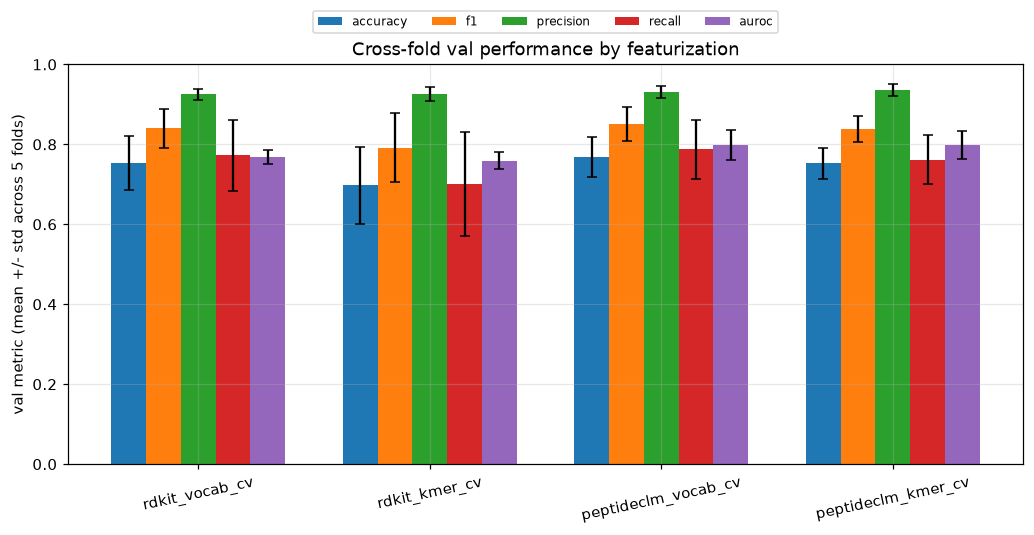

In [10]:
fig, ax = plt.subplots(figsize=(9.5, 5))
x = np.arange(len(EXP_IDS))
width = 0.15
for i, m in enumerate(METRICS):
    means = summary_df[f"val_{m}_mean"].values
    stds = summary_df[f"val_{m}_std"].values
    ax.bar(x + i * width, means, width, yerr=stds, capsize=3, label=m)
ax.set_xticks(x + width * 2)
ax.set_xticklabels(EXP_IDS, rotation=12)
ax.set_ylim(0, 1)
ax.set_ylabel("val metric (mean +/- std across 5 folds)")
ax.legend(fontsize=8, ncol=5, loc="upper center", bbox_to_anchor=(0.5, 1.15))
ax.set_title("Cross-fold val performance by featurization")
fig.tight_layout()
plt.show()


In [11]:
def paired_delta(a: str, b: str, metric: str) -> np.ndarray:
    return fold_metrics[a][f"val/{metric}"].values - fold_metrics[b][f"val/{metric}"].values


comparisons = {
    "peptideclm_vs_rdkit @ vocab_embedding": ("peptideclm_vocab_cv", "rdkit_vocab_cv"),
    "peptideclm_vs_rdkit @ kmer_composition": ("peptideclm_kmer_cv", "rdkit_kmer_cv"),
    "kmer_vs_vocab @ rdkit_descriptors": ("rdkit_kmer_cv", "rdkit_vocab_cv"),
    "kmer_vs_vocab @ peptideclm_embedding": ("peptideclm_kmer_cv", "peptideclm_vocab_cv"),
}

rows = []
for label, (a, b) in comparisons.items():
    for m in METRICS:
        d = paired_delta(a, b, m)
        rows.append({
            "comparison": label, "metric": m,
            "mean_delta": d.mean(), "folds_favoring_first": int((d > 0).sum()),
        })
paired_df = pd.DataFrame(rows)
paired_df.pivot(index="comparison", columns="metric", values="mean_delta").round(3)


metric,accuracy,auroc,f1,precision,recall
comparison,,,,,
kmer_vs_vocab @ peptideclm_embedding,-0.016,-0.000,-0.013,0.005,-0.026
kmer_vs_vocab @ rdkit_descriptors,-0.056,-0.009,-0.048,0.000,-0.072
peptideclm_vs_rdkit @ kmer_composition,0.055,0.038,0.047,0.010,0.061
peptideclm_vs_rdkit @ vocab_embedding,0.016,0.030,0.011,0.006,0.015


In [12]:
paired_df.pivot(index="comparison", columns="metric", values="folds_favoring_first")


metric,accuracy,auroc,f1,precision,recall
comparison,,,,,
kmer_vs_vocab @ peptideclm_embedding,2,3,2,4,2
kmer_vs_vocab @ rdkit_descriptors,1,3,1,3,1
peptideclm_vs_rdkit @ kmer_composition,4,4,4,4,4
peptideclm_vs_rdkit @ vocab_embedding,3,4,3,3,3


In [13]:
fold_difficulty = pd.DataFrame(
    {e: fold_metrics[e]["val/auroc"].values for e in EXP_IDS},
    index=fold_metrics[EXP_IDS[0]]["fold"].values,
)
fold_difficulty.index.name = "val_fold_id"
fold_difficulty["mean_across_featurizations"] = fold_difficulty[EXP_IDS].mean(axis=1)
fold_difficulty.round(3)


,rdkit_vocab_cv,rdkit_kmer_cv,peptideclm_vocab_cv,peptideclm_kmer_cv,mean_across_featurizations
val_fold_id,,,,,
0,0.752,0.754,0.783,0.784,0.768
1,0.776,0.735,0.826,0.820,0.790
2,0.793,0.793,0.739,0.742,0.767
3,0.748,0.752,0.808,0.818,0.782
4,0.772,0.763,0.833,0.824,0.798


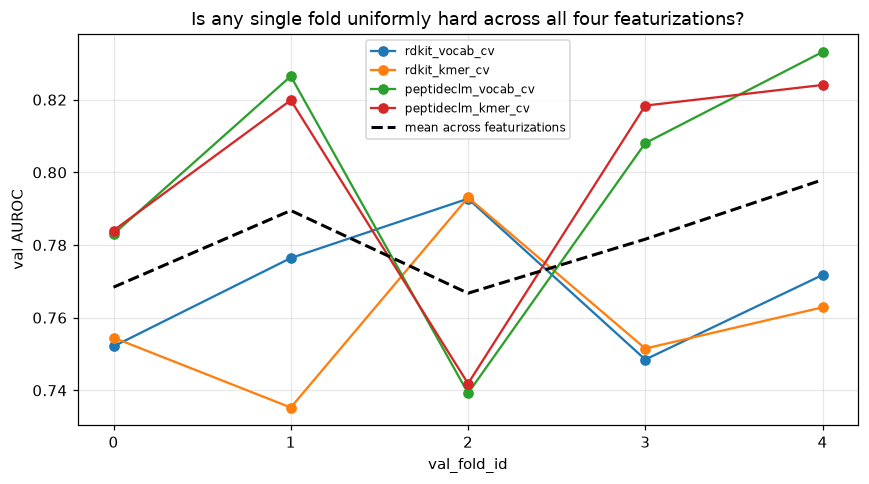

In [14]:
fig, ax = plt.subplots(figsize=(8, 4.5))
for exp_id in EXP_IDS:
    ax.plot(fold_difficulty.index, fold_difficulty[exp_id], "o-", color=COLORS[exp_id], label=exp_id)
ax.plot(fold_difficulty.index, fold_difficulty["mean_across_featurizations"], "k--", lw=2, label="mean across featurizations")
ax.set_xlabel("val_fold_id")
ax.set_ylabel("val AUROC")
ax.set_xticks(fold_difficulty.index)
ax.legend(fontsize=8)
ax.set_title("Is any single fold uniformly hard across all four featurizations?")
fig.tight_layout()
plt.show()


**Reading Section 5 as a whole:** on cross-fold **val** metrics,
`peptideclm_embedding` beats `rdkit_descriptors` consistently -- the
paired per-fold deltas are positive for every metric in both the
`@ vocab_embedding` and `@ kmer_composition` comparisons, and the
`peptideclm_vs_rdkit @ kmer_composition` comparison wins outright in
**5/5 folds** on every metric. The organism-featurization axis
(`vocab_embedding` vs. `kmer_composition`) matters far less on its own,
and its effect *depends on which peptide featurization it's paired with*:
paired with `rdkit_descriptors`, switching to `kmer_composition` costs
real accuracy/recall (-0.056 / -0.072 mean delta, `vocab_embedding` wins
4/5 folds on accuracy/recall); paired with `peptideclm_embedding`, the
same switch is close to a wash (-0.016 accuracy, -0.000 AUROC).

The fold-difficulty check argues against "one hard fold" being responsible
for these differences: `val_fold_id=2` is the *worst* fold for both
`peptideclm_*` runs (AUROC 0.739/0.742) but actually the *best* fold for
both `rdkit_*` runs (AUROC 0.793 both) -- the two featurization families
disagree about which fold is hard, which is more consistent with a real
featurization effect than with one fold's peptide composition dominating
every run alike.

### 7. Organism breakdown

Each row in `cv_results` is scored exactly once as `eval_group == "val"`
across the five CV rounds (it is held out in exactly one round), so
pooling every run's `val` rows reconstructs one out-of-fold prediction per
training-split peptide/organism pair -- a natural per-organism evaluation
set for each featurization. Reuses
`soamp.engine.metrics.compute_metrics_by_organism` directly rather than
recomputing precision/recall/F1/AUROC by hand.


In [15]:
def pooled_val_rows(exp_id: str) -> pd.DataFrame:
    df = cv_results[exp_id]
    return df[df["eval_group"] == "val"].copy()


organism_rows = []
for exp_id in EXP_IDS:
    v = pooled_val_rows(exp_id)
    by_org = compute_metrics_by_organism(v["logit"].values, v["true_label_int"].values, v["organism"].values)
    for org, m in by_org.items():
        organism_rows.append({"exp_id": exp_id, "organism": org, **m})

organism_df = pd.DataFrame(organism_rows)
organism_df.pivot_table(index="organism", columns="exp_id", values="n")


exp_id,peptideclm_kmer_cv,peptideclm_vocab_cv,rdkit_kmer_cv,rdkit_vocab_cv
organism,,,,
Escherichia coli,6714.0,6714.0,6714.0,6714.0
Pseudomonas aeruginosa,4348.0,4348.0,4348.0,4348.0
Staphylococcus aureus,5981.0,5981.0,5981.0,5981.0


In [16]:
organism_df.pivot_table(index="organism", columns="exp_id", values="auroc").round(3)


exp_id,peptideclm_kmer_cv,peptideclm_vocab_cv,rdkit_kmer_cv,rdkit_vocab_cv
organism,,,,
Escherichia coli,0.819,0.815,0.749,0.766
Pseudomonas aeruginosa,0.790,0.791,0.748,0.756
Staphylococcus aureus,0.769,0.767,0.746,0.744


In [17]:
organism_df.pivot_table(index="organism", columns="exp_id", values="precision").round(3)


exp_id,peptideclm_kmer_cv,peptideclm_vocab_cv,rdkit_kmer_cv,rdkit_vocab_cv
organism,,,,
Escherichia coli,0.955,0.947,0.936,0.937
Pseudomonas aeruginosa,0.928,0.922,0.920,0.920
Staphylococcus aureus,0.919,0.917,0.916,0.915


In [18]:
organism_df.pivot_table(index="organism", columns="exp_id", values="recall").round(3)


exp_id,peptideclm_kmer_cv,peptideclm_vocab_cv,rdkit_kmer_cv,rdkit_vocab_cv
organism,,,,
Escherichia coli,0.782,0.833,0.728,0.812
Pseudomonas aeruginosa,0.743,0.771,0.696,0.756
Staphylococcus aureus,0.747,0.740,0.663,0.731


**Reading the organism breakdown:** AUROC favors
`peptideclm_embedding` for every organism, but by very different margins
-- *E. coli* gains the most (0.819/0.815 vs. 0.749/0.766, a ~+0.05-0.07
jump), *P. aeruginosa* a similar amount (~+0.04), while *S. aureus* gains
almost nothing (0.769/0.767 vs. 0.746/0.744, ~+0.02). Precision is high
and fairly flat across organisms and featurizations (0.91-0.96). Recall is
where the organism story diverges most: `rdkit_kmer_cv` has the weakest
recall for every single organism (0.728 / 0.696 / 0.663), consistently
the worst of the four cells -- the `kmer_composition` organism
featurization compounds the `rdkit_descriptors` peptide featurization's
weaknesses rather than compensating for them, at least on this evidence.

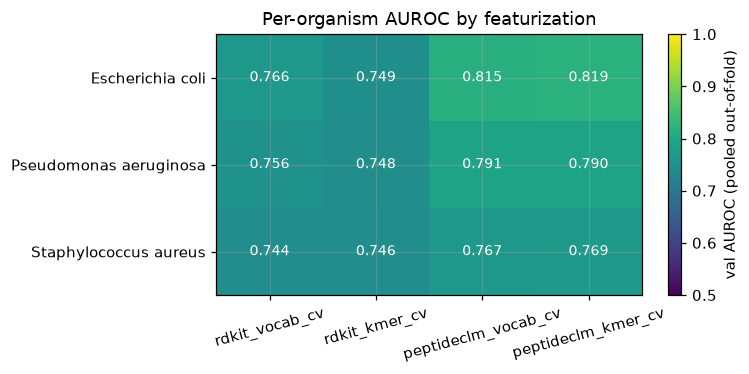

In [19]:
fig, ax = plt.subplots(figsize=(7, 3.5))
pivot = organism_df.pivot_table(index="organism", columns="exp_id", values="auroc")[EXP_IDS]
im = ax.imshow(pivot.values, cmap="viridis", vmin=0.5, vmax=1.0, aspect="auto")
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns, rotation=15)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        ax.text(j, i, f"{pivot.values[i, j]:.3f}", ha="center", va="center", color="white", fontsize=9)
fig.colorbar(im, ax=ax, label="val AUROC (pooled out-of-fold)")
ax.set_title("Per-organism AUROC by featurization")
fig.tight_layout()
plt.show()


### 8. Non-canonical breakdown -- the primary objective

This is the central question of the thesis: does any featurization choice
change how well the classifier does specifically on non-canonical/cyclic
peptides (`has_noncanonical == True`), separately from its effect on
overall performance? First, check how much data actually backs this slice
per fold -- non-canonical peptides are a minority class within the
dataset, so per-fold counts may be too small to trust individually.


In [20]:
nc_fold_counts = {}
for exp_id in EXP_IDS:
    df = cv_results[exp_id]
    v = df[df["eval_group"] == "val"]
    counts = v.groupby(["val_fold_id", "has_noncanonical"]).size().unstack(fill_value=0)
    nc_fold_counts[exp_id] = counts

nc_fold_counts["rdkit_vocab_cv"]


has_noncanonical,False,True
val_fold_id,,
0,2795,444
1,2843,500
2,2771,488
3,2639,936
4,2590,1037


In [21]:
pooled_nc_counts = pd.DataFrame({
    exp_id: pooled_val_rows(exp_id)["has_noncanonical"].value_counts()
    for exp_id in EXP_IDS
}).T
pooled_nc_counts.columns = ["has_noncanonical=False", "has_noncanonical=True"]
pooled_nc_counts["pct_noncanonical"] = (
    pooled_nc_counts["has_noncanonical=True"]
    / (pooled_nc_counts["has_noncanonical=False"] + pooled_nc_counts["has_noncanonical=True"])
).round(3)
pooled_nc_counts


,has_noncanonical=False,has_noncanonical=True,pct_noncanonical
rdkit_vocab_cv,13638,3405,0.2
rdkit_kmer_cv,13638,3405,0.2
peptideclm_vocab_cv,13638,3405,0.2
peptideclm_kmer_cv,13638,3405,0.2


In [22]:
nc_rows = []
for exp_id in EXP_IDS:
    v = pooled_val_rows(exp_id)
    by_nc = compute_metrics_by_organism(v["logit"].values, v["true_label_int"].values, v["has_noncanonical"].values)
    for is_nc, m in by_nc.items():
        nc_rows.append({"exp_id": exp_id, "has_noncanonical": is_nc, **m})

nc_df = pd.DataFrame(nc_rows)
nc_df.pivot_table(index="has_noncanonical", columns="exp_id", values=["n", "precision", "recall", "f1", "auroc"]).round(3)


auroc                                                                  f1                                    \
exp_id           peptideclm_kmer_cv peptideclm_vocab_cv rdkit_kmer_cv rdkit_vocab_cv peptideclm_kmer_cv peptideclm_vocab_cv rdkit_kmer_cv   
has_noncanonical                                                                                                                            
False                         0.789               0.789         0.751          0.766              0.830               0.844         0.812   
True                          0.804               0.814         0.791          0.795              0.873               0.883         0.725   

                                                 n                                                           precision  \
exp_id           rdkit_vocab_cv peptideclm_kmer_cv peptideclm_vocab_cv rdkit_kmer_cv rdkit_vocab_cv peptideclm_kmer_cv   
has_noncanonical                                                                                                         
False                     0.861            13638.0             13638.0       13638.0        13638.0              0.931   
True                      0.751             3405.0              3405.0        3405.0         3405.0              0.952   

                                                                              recall                                                   
exp_id           peptideclm_vocab_cv rdkit_kmer_cv rdkit_vocab_cv peptideclm_kmer_cv peptideclm_vocab_cv rdkit_kmer_cv rdkit_vocab_cv  
has_noncanonical                                                                                                                       
False                          0.927         0.919          0.919              0.749               0.774         0.727          0.809  
True                           0.946         0.955          0.958              0.806               0.827         0.584          0.618

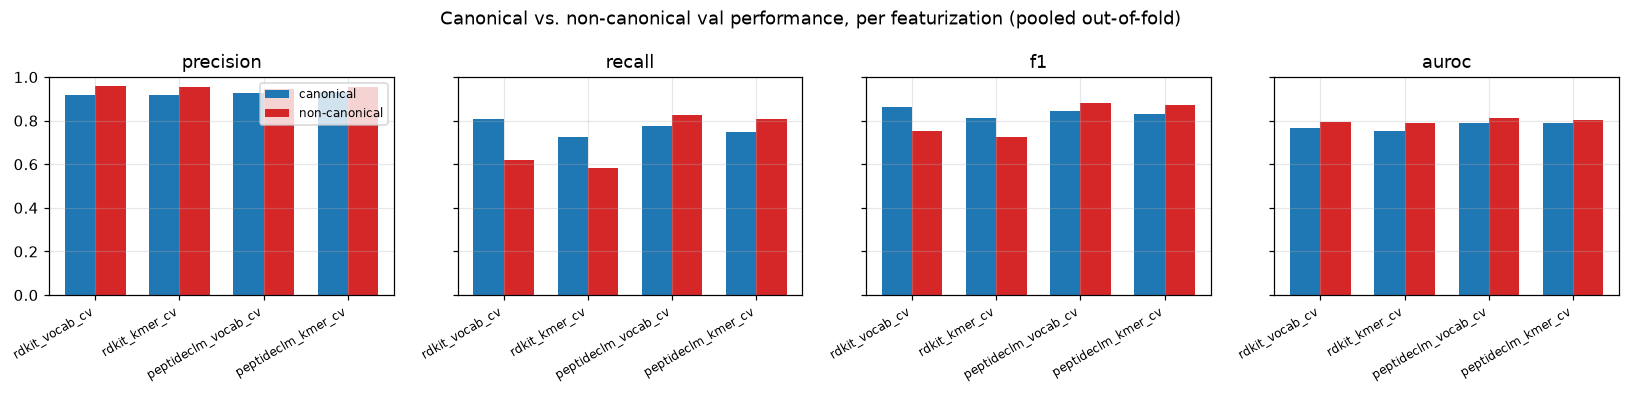

In [23]:
fig, axes = plt.subplots(1, 4, figsize=(15, 3.6), sharey=True)
for ax, m in zip(axes, ["precision", "recall", "f1", "auroc"]):
    pivot = nc_df.pivot_table(index="exp_id", columns="has_noncanonical", values=m).reindex(EXP_IDS)
    x = np.arange(len(EXP_IDS))
    ax.bar(x - 0.18, pivot[False], 0.36, label="canonical", color="tab:blue")
    ax.bar(x + 0.18, pivot[True], 0.36, label="non-canonical", color="tab:red")
    ax.set_xticks(x)
    ax.set_xticklabels(EXP_IDS, rotation=30, ha="right", fontsize=8)
    ax.set_title(m)
    ax.set_ylim(0, 1)
axes[0].legend(fontsize=8)
fig.suptitle("Canonical vs. non-canonical val performance, per featurization (pooled out-of-fold)")
fig.tight_layout()
plt.show()


Cross-break by organism x non-canonical status, where the resulting
slice is large enough to compute a defined AUROC (needs both labels
present) -- single-class slices are reported with `n` and a
`skipped="single_class"` flag rather than a fabricated metric.


In [24]:
cross_rows = []
for exp_id in EXP_IDS:
    v = pooled_val_rows(exp_id)
    for org in sorted(v["organism"].unique()):
        for is_nc in [False, True]:
            mask = (v["organism"] == org) & (v["has_noncanonical"] == is_nc)
            n = int(mask.sum())
            if n == 0:
                continue
            labels = v.loc[mask, "true_label_int"].values
            logits = v.loc[mask, "logit"].values
            if len(set(labels.tolist())) < 2:
                cross_rows.append({"exp_id": exp_id, "organism": org, "has_noncanonical": is_nc, "n": n, "skipped": "single_class"})
                continue
            m = compute_binary_metrics(logits, labels)
            m["n"] = n
            cross_rows.append({"exp_id": exp_id, "organism": org, "has_noncanonical": is_nc, **m})

cross_df = pd.DataFrame(cross_rows)
cross_df.sort_values(["organism", "has_noncanonical", "exp_id"]).reset_index(drop=True)


,exp_id,organism,has_noncanonical,accuracy,f1,precision,recall,auroc,n
0,peptideclm_kmer_cv,Escherichia coli,False,0.764502,0.850319,0.952220,0.768119,0.816966,5482
1,peptideclm_vocab_cv,Escherichia coli,False,0.806457,0.881624,0.943185,0.827608,0.811331,5482
2,rdkit_kmer_cv,Escherichia coli,False,0.734951,0.831809,0.929625,0.752618,0.739171,5482
3,rdkit_vocab_cv,Escherichia coli,False,0.816490,0.890079,0.930333,0.853163,0.759413,5482
4,peptideclm_kmer_cv,Escherichia coli,True,0.835227,0.900927,0.964472,0.845238,0.813501,1232
5,peptideclm_vocab_cv,Escherichia coli,True,0.843344,0.906538,0.961973,0.857143,0.825164,1232
6,rdkit_kmer_cv,Escherichia coli,True,0.649351,0.758929,0.971429,0.622711,0.840408,1232
7,rdkit_vocab_cv,Escherichia coli,True,0.662338,0.768889,0.977401,0.633700,0.870052,1232
8,peptideclm_kmer_cv,Pseudomonas aeruginosa,False,0.725816,0.815421,0.922694,0.730494,0.788525,3370
9,peptideclm_vocab_cv,Pseudomonas aeruginosa,False,0.740653,0.828291,0.918118,0.754474,0.787064,3370


**This is the central result for the thesis question.** Pooled
over all held-out folds (Section 8, cell above the per-organism table),
non-canonical peptides get a *higher* AUROC than canonical ones under
every featurization (0.79-0.81 vs. 0.75-0.79) -- so the representations
can separate active/inactive non-canonical peptides at least as well in
principle. But **recall on non-canonical peptides diverges sharply by
peptide featurization**, while precision stays uniformly high (0.93-0.96)
across the board:

| | canonical recall | non-canonical recall | delta |
|---|---|---|---|
| `rdkit_vocab_cv` | 0.809 | **0.618** | -0.191 |
| `rdkit_kmer_cv` | 0.727 | **0.584** | -0.143 |
| `peptideclm_vocab_cv` | 0.774 | **0.827** | **+0.053** |
| `peptideclm_kmer_cv` | 0.749 | **0.806** | **+0.057** |

`rdkit_descriptors`-based models miss roughly 2 in 5 truly-active
non-canonical peptides (37-42% false-negative rate on this slice) while
keeping precision above 0.93 -- i.e. they become systematically
conservative specifically on non-canonical peptides, predicting
"inactive" too often. `peptideclm_embedding`-based models show the
opposite pattern: recall on non-canonical peptides is *better* than on
canonical peptides.

The organism x non-canonical cross-break above shows this is not an
artifact of one organism: the recall collapse for `rdkit_vocab_cv` /
`rdkit_kmer_cv` on non-canonical peptides is visible in all three --
*E. coli* (0.634 / 0.623 vs. 0.845-0.857 for `peptideclm_*`),
*P. aeruginosa* (0.597 / 0.546 vs. 0.786-0.826), and *S. aureus*
(0.618 / 0.575 vs. 0.782-0.797). Given this thesis's stated objective is a
classifier that performs well on non-canonical peptides specifically,
`rdkit_descriptors` looks like a poor choice for the peptide
representation regardless of which organism featurization it's paired
with, and `peptideclm_embedding` looks like the right one -- a conclusion
that a purely dataset-wide (not non-canonical-aware) comparison in
Section 6 would have understated, since `rdkit_vocab_cv`'s *overall*
recall (0.772, Section 6) looks only moderately worse than
`peptideclm_vocab_cv`'s (0.787), masking a much larger gap that is
concentrated entirely in the non-canonical slice.

One important caveat on statistical weight: non-canonical peptides are
~20% of the val set (3,405 of 17,043 pooled rows, confirmed above) and
per-fold counts range from 444 to 1,037 (Section 8's first table) --
enough to trust the pooled-across-folds numbers above, but individual
folds (especially folds 0-2, with under 500 non-canonical val rows each)
are noisier and shouldn't be over-read on their own.

Prediction confidence on non-canonical rows: is the model just as
confident when it gets a non-canonical peptide *wrong* as when it gets one
right (poor calibration on exactly the slice this thesis cares about), or
does confidence track correctness the way it should?


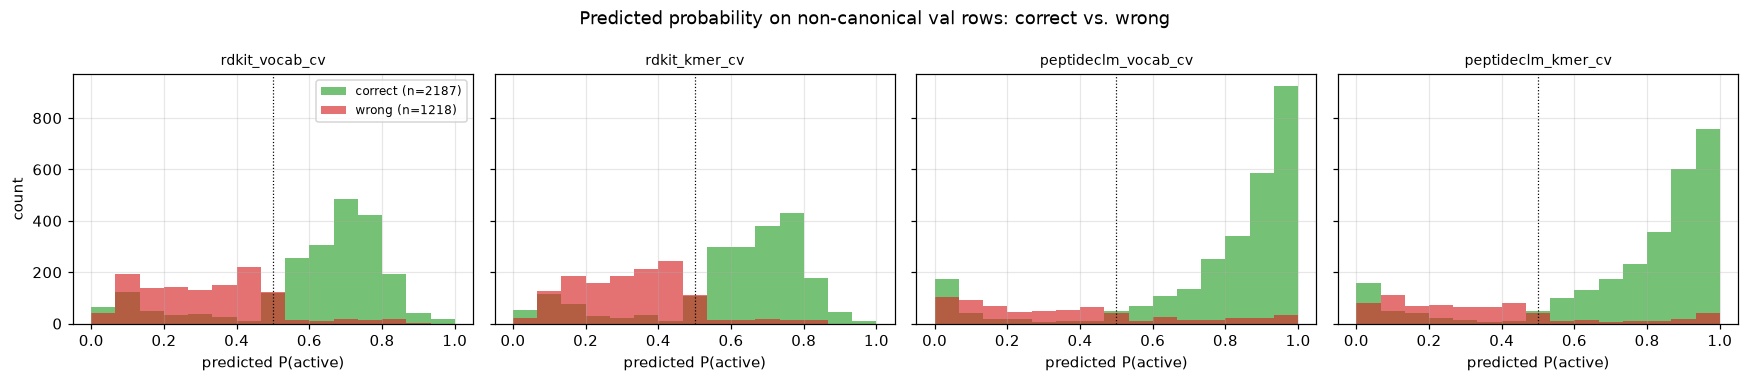

In [25]:
fig, axes = plt.subplots(1, len(EXP_IDS), figsize=(16, 3.5), sharey=True, sharex=True)
for ax, exp_id in zip(axes, EXP_IDS):
    v = pooled_val_rows(exp_id)
    nc = v[v["has_noncanonical"]]
    correct_probs = nc.loc[nc["correct"], "prob"]
    wrong_probs = nc.loc[~nc["correct"], "prob"]
    bins = np.linspace(0, 1, 16)
    ax.hist(correct_probs, bins=bins, alpha=0.65, label=f"correct (n={len(correct_probs)})", color="tab:green")
    ax.hist(wrong_probs, bins=bins, alpha=0.65, label=f"wrong (n={len(wrong_probs)})", color="tab:red")
    ax.axvline(0.5, color="k", lw=0.8, ls=":")
    ax.set_title(exp_id, fontsize=9)
    ax.set_xlabel("predicted P(active)")
axes[0].set_ylabel("count")
axes[0].legend(fontsize=8)
fig.suptitle("Predicted probability on non-canonical val rows: correct vs. wrong")
fig.tight_layout()
plt.show()


### 9. Would any model benefit from training more?

As established in Section 4: no per-epoch or final loss is logged for any
of these runs, so this section relies on the two proxies computed in
Section 5 rather than an actual loss trajectory:

- **Fit-set metric level** -- how far the fit-set metrics get after 5
  epochs. Still mediocre (well below ceiling) *and* a small fit-val gap is
  the underfitting signature (more epochs plausibly helps).
- **Fit-minus-val gap** -- a large, consistent gap is the overfitting
  signature at the current epoch budget (more epochs plausibly hurts,
  since fit performance is already outpacing generalization).


In [26]:
fit_level = pd.DataFrame({e: fold_metrics[e][[f"fit/{m}" for m in METRICS]].mean().values for e in EXP_IDS}, index=METRICS).T
fit_level.round(3)


,accuracy,f1,precision,recall,auroc
rdkit_vocab_cv,0.796,0.872,0.935,0.818,0.824
rdkit_kmer_cv,0.755,0.840,0.941,0.759,0.820
peptideclm_vocab_cv,0.837,0.898,0.962,0.843,0.906
peptideclm_kmer_cv,0.812,0.880,0.966,0.808,0.905


In [27]:
gap_means = gap_df.groupby("exp_id")[[f"gap_{m}" for m in METRICS]].mean()
gap_means.columns = METRICS
gap_means = gap_means.reindex(EXP_IDS)
gap_means.round(3)


,accuracy,f1,precision,recall,auroc
exp_id,,,,,
rdkit_vocab_cv,0.043,0.032,0.009,0.045,0.055
rdkit_kmer_cv,0.057,0.048,0.015,0.059,0.061
peptideclm_vocab_cv,0.069,0.047,0.031,0.055,0.108
peptideclm_kmer_cv,0.060,0.041,0.030,0.047,0.107


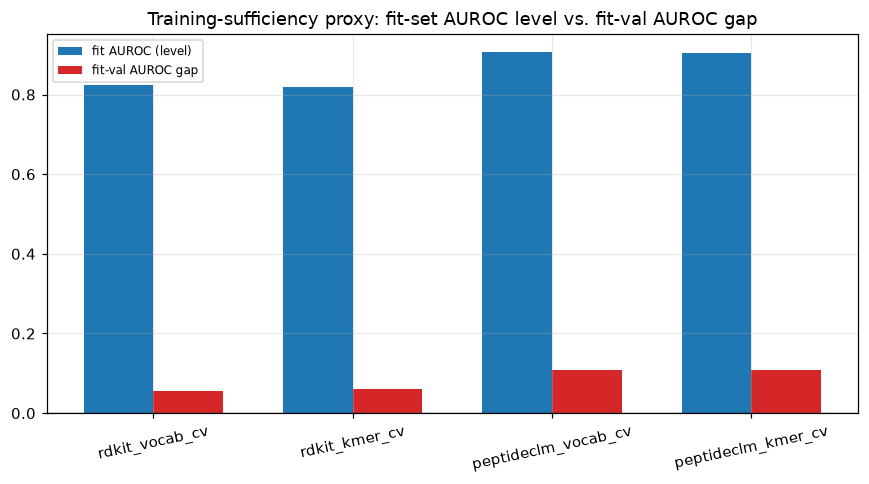

In [28]:
fig, ax = plt.subplots(figsize=(8, 4.5))
x = np.arange(len(EXP_IDS))
width = 0.35
ax.bar(x - width / 2, fit_level["auroc"], width, label="fit AUROC (level)", color="tab:blue")
ax.bar(x + width / 2, gap_means["auroc"], width, label="fit-val AUROC gap", color="tab:red")
ax.axhline(0, color="k", lw=0.8)
ax.set_xticks(x)
ax.set_xticklabels(EXP_IDS, rotation=12)
ax.legend(fontsize=8)
ax.set_title("Training-sufficiency proxy: fit-set AUROC level vs. fit-val AUROC gap")
fig.tight_layout()
plt.show()


### 10. Conclusions

**Whole-picture featurization effect (Section 6).** Peptide featurization
is the dominant axis: `peptideclm_embedding` beats `rdkit_descriptors`
on every cross-fold val metric, in every paired per-fold comparison (up to
5/5 folds for the `@ kmer_composition` pairing), for AUROC gains of
roughly +0.03 to +0.04. Organism featurization (`vocab_embedding` vs.
`kmer_composition`) matters much less on its own and its effect is
conditional: it costs real accuracy/recall when paired with
`rdkit_descriptors`, but is close to a wash when paired with
`peptideclm_embedding`.

**Non-canonical peptides -- the primary objective (Section 8).** This is
where the featurization choice matters most, and in a way a whole-dataset
average understates. `rdkit_descriptors`-based models lose 0.14-0.19 of
recall specifically on non-canonical peptides relative to canonical ones
(down to 0.58-0.62), while keeping precision high (>0.93) -- i.e. they
become conservative and miss a large fraction of truly-active
non-canonical peptides. `peptideclm_embedding`-based models show the
opposite pattern, with *better* recall on non-canonical peptides than on
canonical ones (0.81-0.83). This holds separately within all three
organisms, so it is not one organism's peculiarity.

**Recommendation.** `peptideclm_embedding` + `vocab_embedding`
(`peptideclm_vocab_cv`) is the strongest cell overall -- it leads or ties
on every whole-dataset val metric in Section 6 *and* has the best
non-canonical recall (0.827) of the four cells. `peptideclm_kmer_cv` is a
close second on both counts (non-canonical recall 0.806). Between the two,
there is no evidence here that the `kmer_composition` organism
featurization -- which needs the extra reference-genome pipeline and is
currently only populated for 3 organisms -- buys anything over
`vocab_embedding` once the peptide side is `peptideclm_embedding`; that
extra infrastructure is better justified once organism coverage grows
past the current 3-organism scope. `rdkit_descriptors`, in either
organism pairing, should not be carried forward if the non-canonical
objective is the priority, even though it is a cheaper, dependency-light
featurization.

**Would more training help (Section 9)?** Not obviously, and the honest
answer needs a real loss curve this notebook doesn't have (Section 4's
caveat). What is available points toward more epochs being *counter*-
productive specifically for the `peptideclm_*` cells: they already reach
a higher fit-set AUROC (~0.905-0.906) with a larger fit-val gap
(~0.107-0.108) than the `rdkit_*` cells (fit AUROC ~0.82, gap
~0.055-0.061) at the same 5-epoch budget -- the signature of a model that
is already fitting the training split aggressively, where training longer
would plausibly widen the gap rather than close it. The `rdkit_*` cells'
smaller gap and lower fit-set ceiling leave more nominal headroom to keep
training, but that would not address the non-canonical recall problem
above, which looks like a representation-capacity issue rather than an
undertrained one. A follow-up run with per-epoch loss logging added to
`Trainer`/`train_and_evaluate_fold` (see Section 4) would turn this from
an informed guess into a real answer, particularly for deciding whether
the `peptideclm_*` cells would benefit from early stopping before 5
epochs rather than training longer.

**Scope of this analysis.** Everything above comes from 5-fold
cross-validation over the *train* split only -- the held-out test split
was never touched. Before finalizing `peptideclm_embedding` +
`vocab_embedding` as the production choice, it is worth confirming this
ranking holds on the real held-out test benchmark via
`pipeline/train.py --config config/train/exp_peptideclm_vocab.yaml`
(the single-split counterpart already scaffolded in this repo), including
a test-set non-canonical breakdown to check this recall pattern replicates
outside cross-validation.
